
# Análisis funcional comparativo: Coding-only vs Coding+ncRNA

## Objetivo general

Evaluar si la incorporación de genes no codificantes modifica la interpretación biológica de los cambios asociados a cáncer de ovario.

## Ensayos incluidos

1. Expresión diferencial (DEGs).
2. Enriquecimiento funcional (GO, Reactome, KEGG).
3. Actividad de vías mediante PROGENy.
4. Identificación de ncRNAs

Este notebook asume que los objetos AnnData ya han sido integrados, anotados y evaluados estructuralmente.


## Librerías

In [1]:
import importlib.util

packages = {
    "scanpy": "scanpy",
    "pandas": "pandas",
    "numpy": "numpy",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib",
    "gseapy": "gseapy",
    "decoupler": "decoupler",
    "matplotlib_venn": "matplotlib-venn"
}

for import_name, pip_name in packages.items():
    if importlib.util.find_spec(import_name) is not None:
        print(f"{import_name}: instalado")
    else:
        print(f"{import_name}: NO instalado → instalar con pip install {pip_name}")

scanpy: instalado
pandas: instalado
numpy: instalado
seaborn: instalado
matplotlib: instalado
gseapy: NO instalado → instalar con pip install gseapy
decoupler: NO instalado → instalar con pip install decoupler
matplotlib_venn: NO instalado → instalar con pip install matplotlib-venn


In [2]:
%pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 26.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install decoupler

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 94.6 MB/s  0:00:00m eta 0:00:01
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19971 sha256=f6617f2476cebb9bd05cdccffdd703f70cffc9fd333471d100503bfa38d97d69
  Stored in directory: /teamspace/studios/this_studio/.cache/pip/wheels/d6/19/ee/0a6a1793d91c449563b49ccab57ce52da3e6fab7614836bd8c
Successfully built docrep
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [decoupler]/6 [decoupler]
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install matplotlib-venn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=afaf77a8ede0c831b5afe77158668d3a4406b072ccce117644cec2db42909be4
  Stored in directory: /teamspace/studios/this_studio/.cache/pip/wheels/c2/47/0c/f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


In [1]:

import scanpy as sc
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import gseapy as gp
import decoupler as dc

from matplotlib_venn import venn2


## Carga de datos y emparejamiento de células

In [2]:

adata_coding = sc.read_h5ad("adata_coding_integrated.h5ad")
adata_ncrna = sc.read_h5ad("adata_ncrna_integrated.h5ad")


In [3]:
# Structural summary of the loaded objects
print("Coding-only:", adata_coding)
print("Coding+ncRNA:", adata_ncrna)

print("Dimensions:")
print(f"coding:       {adata_coding.n_obs:,} cells x {adata_coding.n_vars:,} genes")
print(f"coding+ncRNA: {adata_ncrna.n_obs:,} cells x {adata_ncrna.n_vars:,} genes")

Coding-only: AnnData object with n_obs × n_vars = 43570 × 30795
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'
Coding+ncRNA: An

In [4]:
print("Condition - coding")
print(adata_coding.obs["Condition"].value_counts())

print("Condition - coding+ncRNA")
print(adata_ncrna.obs["Condition"].value_counts())

print("Cell type - coding")
print(adata_coding.obs["annotation"].value_counts())

print("Cell type - coding+ncRNA")
print(adata_ncrna.obs["annotation"].value_counts())

Condition - coding
Condition
omt        26166
tumor      12460
control     4944
Name: count, dtype: int64
Condition - coding+ncRNA
Condition
omt        24639
tumor      10599
control     4728
Name: count, dtype: int64
Cell type - coding
annotation
Epithelial        17258
CD8T              10102
CD8Tex             9956
Mono/Macro         3092
B                  1354
Fibroblasts         808
Tprolif             411
Malignant           274
Plasma              252
Endothelial          61
Myofibroblasts        2
Name: count, dtype: int64
Cell type - coding+ncRNA
annotation
Epithelial        17061
CD8Tex             9037
CD8T               6309
Mono/Macro         3973
B                  1383
Fibroblasts         726
Tprolif             498
Malignant           473
Plasma              443
Endothelial          61
Myofibroblasts        2
Name: count, dtype: int64


In [5]:
# Find shared cells between both AnnData objects
common_cells = adata_coding.obs_names.intersection(adata_ncrna.obs_names)

print(f"Cells in coding:       {adata_coding.n_obs:,}")
print(f"Cells in coding+ncRNA: {adata_ncrna.n_obs:,}")
print(f"Common cells:         {len(common_cells):,}")

adata_coding_common = adata_coding[common_cells, :].copy()
adata_ncrna_common = adata_ncrna[common_cells, :].copy()

# To reorder the ncrna object to follow the same order as coding
adata_ncrna_common = adata_ncrna_common[adata_coding_common.obs_names, :].copy()

print("After pairing:")
print("coding_common:", adata_coding_common)
print("ncrna_common:", adata_ncrna_common)

Cells in coding:       43,570
Cells in coding+ncRNA: 39,966
Common cells:         39,823


After pairing:
coding_common: AnnData object with n_obs × n_vars = 39823 × 30795
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [6]:
# Check that the metadata match after pairing
metadata_cols = ["Sample", "Condition", "annotation"]
metadata_cols = [c for c in metadata_cols if c in adata_coding_common.obs.columns and c in adata_ncrna_common.obs.columns]

for col in metadata_cols:
    same = (adata_coding_common.obs[col].astype(str).values == adata_ncrna_common.obs[col].astype(str).values).all()
    print(f"{col}: {'OK' if same else 'Check'}")

print("Common composition per condition:")
print(adata_coding_common.obs["Condition"].value_counts())

print("Common composition per cell type:")
print(adata_coding_common.obs["annotation"].value_counts())

Sample: OK
Condition: OK
annotation: Check
Common composition per condition:
Condition
omt        24600
tumor      10507
control     4716
Name: count, dtype: int64
Common composition per cell type:
annotation
Epithelial        14432
CD8Tex             9805
CD8T               9767
Mono/Macro         2908
B                  1326
Fibroblasts         680
Tprolif             395
Malignant           239
Plasma              212
Endothelial          57
Myofibroblasts        2
Name: count, dtype: int64



# Ensayo 1. Expresión diferencial

## Objetivo

Identificar genes diferencialmente expresados entre condiciones dentro de cada tipo celular.


In [7]:
adata_coding

AnnData object with n_obs × n_vars = 43570 × 30795
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [8]:
adata_ncrna

AnnData object with n_obs × n_vars = 39966 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [9]:
celltypes_to_analyze = ["Epithelial", "CD8Tex", "Mono/Macro", "Malignant"]

print("Available cell types:")
print(adata_coding_common.obs["annotation"].value_counts())

print(f"Selected cell types: {celltypes_to_analyze}")

Available cell types:
annotation
Epithelial        14432
CD8Tex             9805
CD8T               9767
Mono/Macro         2908
B                  1326
Fibroblasts         680
Tprolif             395
Malignant           239
Plasma              212
Endothelial          57
Myofibroblasts        2
Name: count, dtype: int64
Selected cell types: ['Epithelial', 'CD8Tex', 'Mono/Macro', 'Malignant']


In [10]:
# Function for runming the DEG by celltype
def run_deg_by_celltype(adata, celltype, group, layer=None):
    'Ejecuta rank_genes_groups dentro de un único tipo celular.'
    adata_ct = adata[adata.obs["annotation"] == celltype, :].copy()
    
    print(adata_ct)
    print("Cells per condition:")
    print(adata_ct.obs["Condition"].value_counts())
    
    if adata_ct.n_obs == 0:
        raise ValueError(f"There are no cell annotated as {celltype!r}.")
    
    if group not in adata_ct.obs["Condition"].astype(str).unique():
        raise ValueError(f"The group {group!r} is not present in Condition for {celltype!r}.")
    
    sc.tl.rank_genes_groups(
        adata_ct,
        groupby="Condition",
        groups=[group],
        reference="rest",
        method="wilcoxon",
        layer=layer,
        use_raw=False
    )
    
    deg = sc.get.rank_genes_groups_df(adata_ct, group=group)
    return adata_ct, deg


In [11]:
# adata_ct_coding, deg_coding = run_deg_by_celltype(
#     adata_coding_common,
#     celltype=celltypes_to_analyze,
#     group="tumor",
#     layer="logcounts"
# )

# deg_coding.head(20)
deg_results_coding = {}
adata_ct_results_coding = {}

for celltype in celltypes_to_analyze:
    print(f"\n==============================")
    print(f"Running DEG for: {celltype}")
    print(f"==============================")
    
    adata_ct, deg = run_deg_by_celltype(
        adata_coding_common,
        celltype=celltype,
        group="tumor",
        layer="logcounts"
    )
    
    adata_ct_results_coding[celltype] = adata_ct
    deg_results_coding[celltype] = deg


Running DEG for: Epithelial


AnnData object with n_obs × n_vars = 14432 × 30795
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'
Cells per condition:
Conditio

In [12]:
deg_results_coding["Epithelial"].head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MEIS2,73.992928,6.574618,0.0,0.0
1,CDKN2A,64.868767,4.028030,0.0,0.0
2,MUC1,61.211266,2.373459,0.0,0.0
3,BST2,60.781029,3.707051,0.0,0.0
4,MPPED2,60.741425,7.726506,0.0,0.0
5,NDUFB9,58.356953,2.343813,0.0,0.0
6,PTK2,56.805817,1.761975,0.0,0.0
7,RACK1,56.178528,2.050489,0.0,0.0
8,CD47,55.923969,1.792646,0.0,0.0
9,CANX,54.936413,1.764437,0.0,0.0


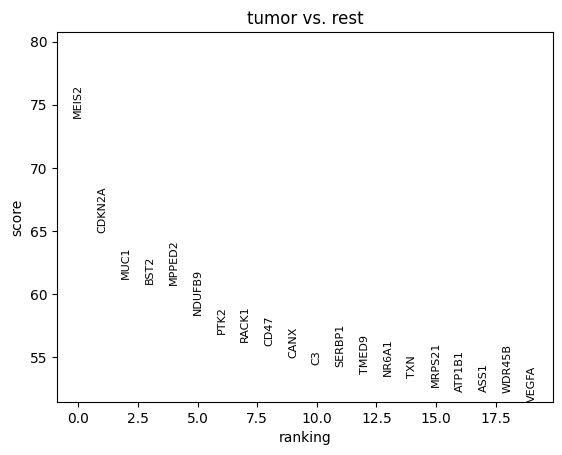

In [13]:
sc.pl.rank_genes_groups(adata_ct_results_coding["Epithelial"], n_genes=20, show=True)

In [14]:
deg_results_coding["CD8Tex"].head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,IFI44L,31.388233,3.177913,2.928623e-216,9.018693e-212
1,IFI44,27.720894,2.361875,3.910334e-169,6.020937e-165
2,RBPJ,25.525665,1.627789,1.023116e-143,6.301371e-140
3,IFI6,25.465673,2.146708,4.733827e-143,2.429637e-139
4,MX1,25.337870,2.015588,1.222645e-141,5.378764e-138
5,HSPA1B,24.937540,1.745062,2.915166e-137,9.974726e-134
6,FNDC3B,24.344374,1.532508,6.650059e-131,1.706571e-127
7,SRGAP3,24.302341,1.872418,1.851696e-130,4.386383e-127
8,ISG15,23.954557,1.993818,8.283052e-127,1.594229e-123
9,IFI27,23.886108,3.781637,4.270797e-126,7.736423e-123


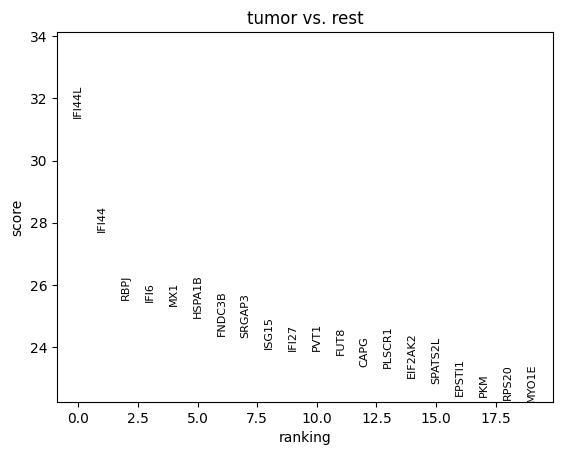

In [15]:
sc.pl.rank_genes_groups(adata_ct_results_coding["CD8Tex"], n_genes=20, show=True)

In [16]:
deg_results_coding["Mono/Macro"].head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,SPP1,19.757450,4.703119,6.921468e-87,2.131466e-82
1,ENO1,17.819099,1.715360,5.023805e-71,5.156936e-67
2,TPI1,17.130449,1.773280,8.797178e-66,3.386364e-62
3,C15orf48,16.373535,2.614496,2.955335e-60,1.011217e-56
4,GAPDH,16.152197,1.520109,1.095890e-58,3.374794e-55
5,LDHA,16.116531,1.931695,1.952632e-58,5.010942e-55
6,PKM,15.993834,1.447030,1.410749e-57,3.341847e-54
7,MIF,15.950624,1.917552,2.820673e-57,6.204472e-54
8,IL4I1,15.167048,2.544630,5.844737e-52,9.999372e-49
9,ADAM8,14.824082,2.119120,1.023694e-49,1.576232e-46


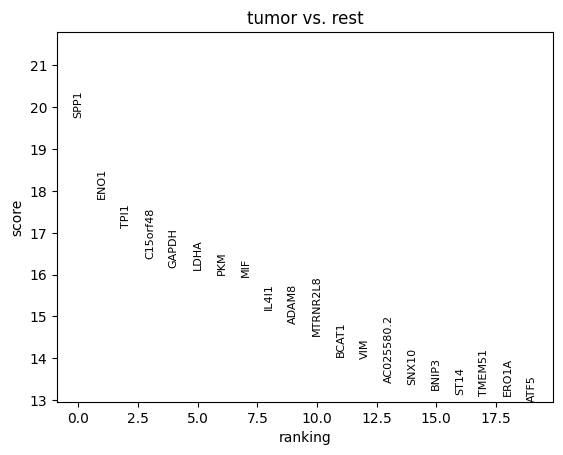

In [17]:
sc.pl.rank_genes_groups(adata_ct_results_coding["Mono/Macro"], n_genes=20, show=True)

In [18]:
deg_results_coding["Malignant"].head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CDKN2A,10.260296,9.481640,1.063799e-24,3.275968e-20
1,RHEX,10.061559,5.606120,8.169455e-24,1.257892e-19
2,PLCG2,9.845010,3.726116,7.203227e-23,7.394113e-19
3,NSD1,9.640648,3.404950,5.384725e-22,4.145565e-18
4,NFIB,9.451284,5.975313,3.346985e-21,1.472434e-17
5,ZRANB2,9.411912,3.282100,4.871936e-21,1.730294e-17
6,PPP4R2,9.396913,3.333360,5.618751e-21,1.730294e-17
7,CNOT6,9.367852,4.253683,7.402358e-21,2.072324e-17
8,BST2,9.308793,3.602959,1.292930e-20,3.062751e-17
9,KCNQ1OT1,9.262858,5.914190,1.990309e-20,4.377968e-17


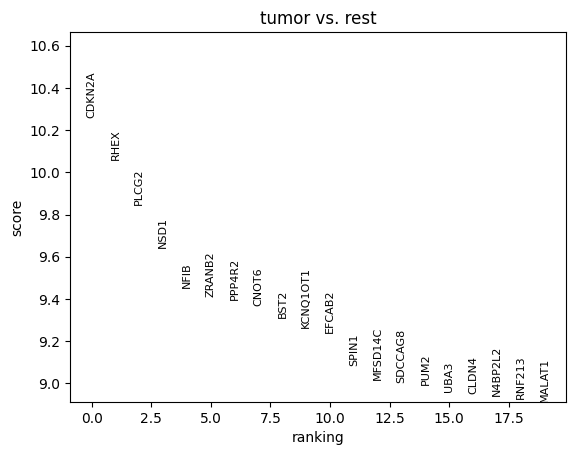

In [19]:
sc.pl.rank_genes_groups(adata_ct_results_coding["Malignant"], n_genes=20, show=True)

In [20]:
deg_results_ncrna = {}
adata_ct_results_ncrna = {}

for celltype in celltypes_to_analyze:
    print(f"\n==============================")
    print(f"Running DEG for: {celltype}")
    print(f"==============================")
    
    adata_ct, deg = run_deg_by_celltype(
        adata_ncrna_common,
        celltype=celltype,
        group="tumor",
        layer="logcounts"
    )
    
    adata_ct_results_ncrna[celltype] = adata_ct
    deg_results_ncrna[celltype] = deg


Running DEG for: Epithelial


AnnData object with n_obs × n_vars = 16959 × 47611
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'
Cells per condition:
Conditio

In [21]:
deg_results_ncrna["Epithelial"].head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MEIS2,84.639282,6.512343,0.0,0.0
1,CDKN2A,77.112755,4.288149,0.0,0.0
2,ENSG00000293253,70.979187,6.193414,0.0,0.0
3,BST2,70.530098,3.721334,0.0,0.0
4,MPPED2,68.636055,7.645487,0.0,0.0
5,MT-RNR1,66.973854,1.392633,0.0,0.0
6,NDUFB9,66.789925,2.298074,0.0,0.0
7,C3,65.663750,3.328271,0.0,0.0
8,PTK2,65.428207,1.723560,0.0,0.0
9,SERBP1,63.774982,1.871735,0.0,0.0


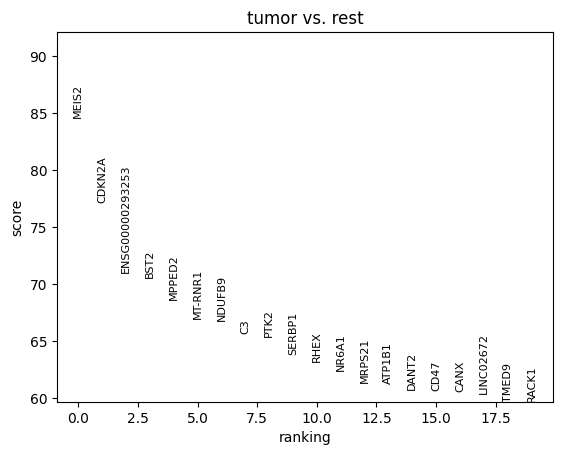

In [22]:
sc.pl.rank_genes_groups(adata_ct_results_ncrna["Epithelial"], n_genes=20, show=True)

In [23]:
deg_results_ncrna["CD8Tex"].head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,IFI44L,28.369076,3.481000,4.869617e-177,1.159237e-172
1,RBPJ,26.238163,1.977415,9.756235e-152,1.548347e-147
2,IFI44,25.241953,2.642851,1.388122e-140,1.652247e-136
3,SRGAP3,24.229223,2.208002,1.095055e-129,6.517081e-126
4,MX1,22.685221,2.146017,6.269133e-114,2.984797e-110
5,FUT8,22.466301,1.642953,8.867514e-112,3.838102e-108
6,EPSTI1,21.612370,1.798641,1.374145e-103,4.089027e-100
7,ISG15,20.878523,2.013364,8.394649e-97,2.103567e-93
8,FNDC3B,20.774775,1.491387,7.320552e-96,1.742694e-92
9,PVT1,20.126822,1.634804,4.296930e-90,8.894832e-87


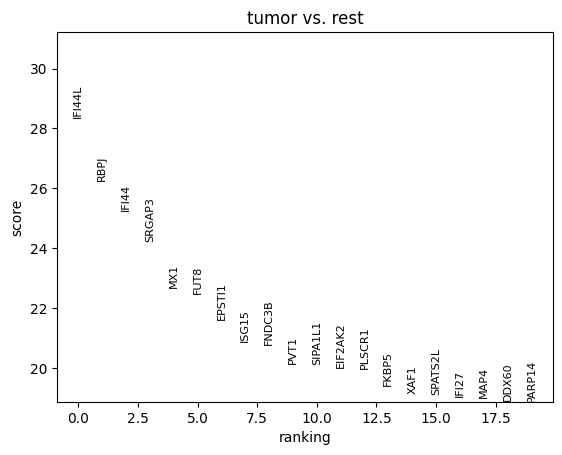

In [24]:
sc.pl.rank_genes_groups(adata_ct_results_ncrna["CD8Tex"], n_genes=20, show=True)

In [25]:
deg_results_ncrna["Mono/Macro"].head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,SPP1,26.729906,4.271660,2.114749e-157,5.034267e-153
1,ENO1,26.176958,1.724671,4.862959e-151,5.788259e-147
2,TPI1,25.019442,1.711159,3.756482e-138,2.554998e-134
3,PKM,24.738775,1.506621,4.094655e-135,2.166118e-131
4,LDHA,23.977011,1.882894,4.831528e-127,2.300339e-123
5,GAPDH,23.735752,1.544192,1.541978e-124,6.674103e-121
6,ADAM8,21.381660,1.920670,1.979558e-101,4.960461e-98
7,VIM,21.122974,1.222959,4.891600e-99,1.164470e-95
8,CAPG,20.974531,1.345791,1.120664e-97,2.425269e-94
9,ST14,20.873760,1.758649,9.274480e-97,1.839864e-93


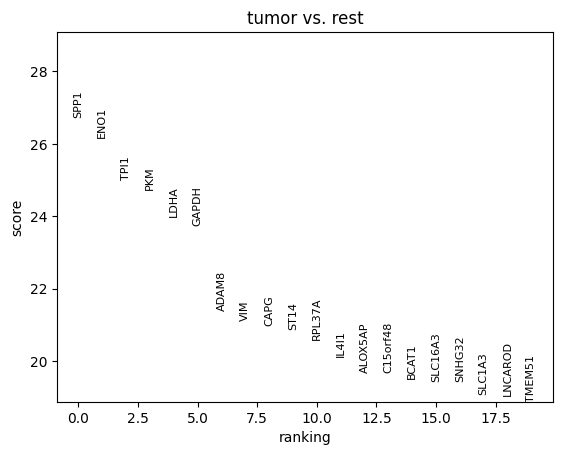

In [26]:
sc.pl.rank_genes_groups(adata_ct_results_ncrna["Mono/Macro"], n_genes=20, show=True)

In [27]:
deg_results_ncrna["Malignant"].head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CDKN2A,14.930932,5.581331,2.073483e-50,9.872059e-46
1,NFIB,14.869768,5.934895,5.179240e-50,1.232944e-45
2,DANT2,14.628798,5.421354,1.840091e-48,2.920285e-44
3,MEIS2,14.480310,5.976924,1.613668e-47,1.920708e-43
4,RHEX,14.206180,5.843917,8.387855e-46,6.655903e-42
5,EFCAB2,14.080904,3.429269,4.976875e-45,3.385057e-41
6,KCNQ1OT1,14.058429,4.882937,6.838791e-45,4.070021e-41
7,N4BP2L2,13.703238,2.839943,9.709679e-43,5.136528e-39
8,PPP4R2,13.667497,3.193207,1.587627e-42,7.558851e-39
9,BST2,13.652390,3.791513,1.953634e-42,8.455861e-39


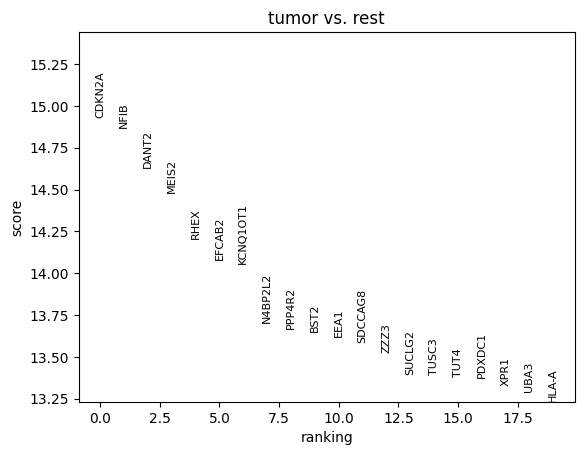

In [28]:
sc.pl.rank_genes_groups(adata_ct_results_ncrna["Malignant"], n_genes=20, show=True)

In [27]:
# ESTO ES CON TODAS LAS POBLACIONES CELULARES-->PREGUNTAR A RODRIGO SI QUITAR ESTO O NO
sc.tl.rank_genes_groups(
    adata_coding_common,
    groupby="Condition",
    method="wilcoxon"
)

deg_coding_all_cellTypes = sc.get.rank_genes_groups_df(
    adata_coding_common,
    group="tumor"
)

deg_coding_all_cellTypes.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,MUC1,90.172539,3.360719,0.0,0.0
1,MEIS2,89.335564,4.724521,0.0,0.0
2,PTK2,86.809708,2.614120,0.0,0.0
3,CDKN2A,85.383415,3.634601,0.0,0.0
4,RHEX,85.062149,3.714161,0.0,0.0


In [28]:
# ESTO ES CON TODAS LAS POBLACIONES CELULARES-->PREGUNTAR A RODRIGO SI QUITAR ESTO O NO
sc.tl.rank_genes_groups(
    adata_ncrna_common,
    groupby="Condition",
    method="wilcoxon"
)

deg_ncrna_all_cellTypes = sc.get.rank_genes_groups_df(
    adata_ncrna_common,
    group="tumor"
)

deg_ncrna_all_cellTypes.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,MEIS2,89.291832,4.687924,0.0,0.0
1,PTK2,87.009712,2.591385,0.0,0.0
2,MT-RNR1,85.893982,1.478959,0.0,0.0
3,CDKN2A,85.207474,3.612665,0.0,0.0
4,RHEX,84.313995,3.767326,0.0,0.0



## Comparación de genes diferenciales

Comparar posteriormente los DEGs obtenidos en ambos objetos.


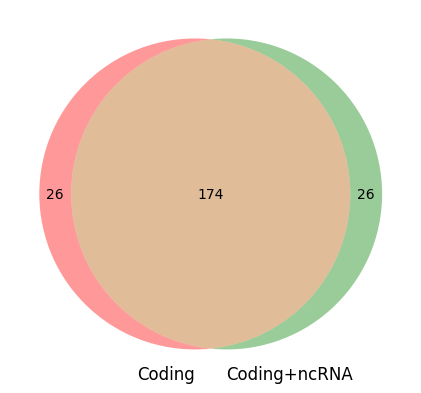

In [ ]:
# ESTO ESO CON LAS CÉLULAS COMUNES
genes_a = set(deg_coding_all_cellTypes["names"].head(200))

# sustituir por resultados equivalentes
genes_b = set(deg_ncrna_all_cellTypes["names"].head(200))

venn2(
    [genes_a, genes_b],
    set_labels=("Coding", "Coding+ncRNA")
)

plt.show()


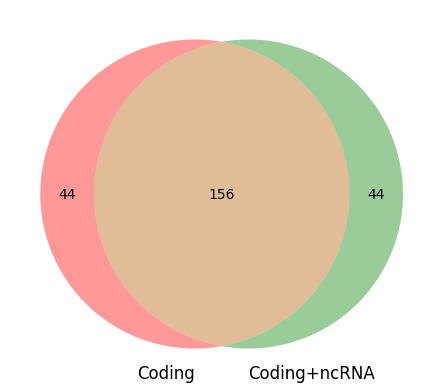

In [30]:
# ESTO ESO CON SOLO EPITHELIAL
genes_a = set(deg_results_coding["Epithelial"]["names"].head(200))

# sustituir por resultados equivalentes
genes_b = set(deg_results_ncrna["Epithelial"]["names"].head(200))

venn2(
    [genes_a, genes_b],
    set_labels=("Coding", "Coding+ncRNA")
)

plt.show()


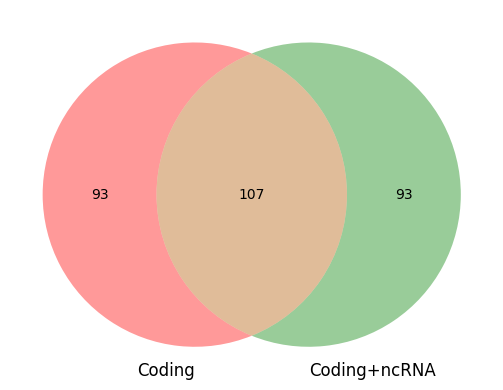

In [31]:
# ESTO ESO CON SOLO CD8Tex
genes_a = set(deg_results_coding["CD8Tex"]["names"].head(200))

# sustituir por resultados equivalentes
genes_b = set(deg_results_ncrna["CD8Tex"]["names"].head(200))

venn2(
    [genes_a, genes_b],
    set_labels=("Coding", "Coding+ncRNA")
)

plt.show()


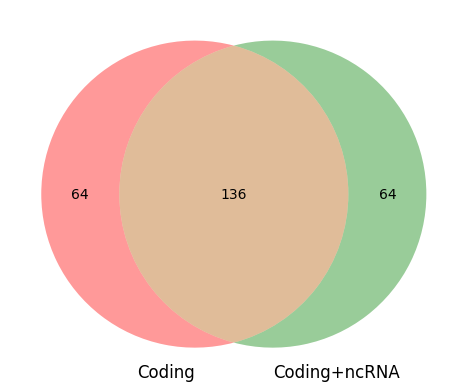

In [32]:
# ESTO ESO CON SOLO Mono/Macro
genes_a = set(deg_results_coding["Mono/Macro"]["names"].head(200))

# sustituir por resultados equivalentes
genes_b = set(deg_results_ncrna["Mono/Macro"]["names"].head(200))

venn2(
    [genes_a, genes_b],
    set_labels=("Coding", "Coding+ncRNA")
)

plt.show()


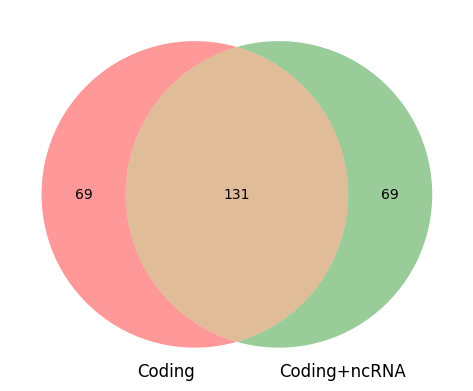

In [33]:
# ESTO ESO CON SOLO Malignant
genes_a = set(deg_results_coding["Malignant"]["names"].head(200))

# sustituir por resultados equivalentes
genes_b = set(deg_results_ncrna["Malignant"]["names"].head(200))

venn2(
    [genes_a, genes_b],
    set_labels=("Coding", "Coding+ncRNA")
)

plt.show()

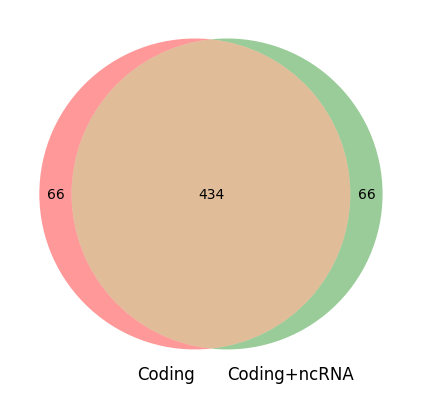

In [ ]:
# ESTO ES CON LAS CÉLULAS COMUNES
genes_a = set(deg_coding_all_cellTypes["names"].head(500))

# sustituir por resultados equivalentes
genes_b = set(deg_ncrna_all_cellTypes["names"].head(500))

venn2(
    [genes_a, genes_b],
    set_labels=("Coding", "Coding+ncRNA")
)

plt.show()


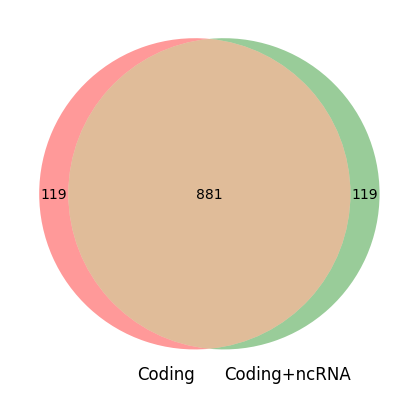

In [ ]:
# ESTO ES CON LAS CÉLULAS COMUNES
genes_a = set(deg_coding_all_cellTypes["names"].head(1000))

# sustituir por resultados equivalentes
genes_b = set(deg_ncrna_all_cellTypes["names"].head(1000))

venn2(
    [genes_a, genes_b],
    set_labels=("Coding", "Coding+ncRNA")
)

plt.show()



# Ensayo 2. Enriquecimiento funcional

## Objetivo

Identificar procesos biológicos alterados.


In [36]:

gene_list_coding = deg_coding_all_cellTypes["names"].head(300).tolist()

enr_coding = gp.enrichr(
    gene_list=gene_list_coding,
    gene_sets=[
        "GO_Biological_Process_2023",
        "Reactome_2022",
        "KEGG_2021_Human"
    ],
    organism="human",
    outdir=None
)

enr_coding.results.head()


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Aerobic Electron Transport Chain (GO:0019646),10/68,6.695290e-08,0.000080,0,0,11.677765,192.908222,NDUFB9;NDUFA8;UQCRQ;NDUFS5;UQCRC1;CYC1;COX6A1;...
1,GO_Biological_Process_2023,Mitochondrial ATP Synthesis Coupled Electron T...,10/70,8.896780e-08,0.000080,0,0,11.287356,183.250132,NDUFB9;NDUFA8;UQCRQ;NDUFS5;UQCRC1;CYC1;COX6A1;...
2,GO_Biological_Process_2023,Maintenance Of Blood-Brain Barrier (GO:0035633),7/29,1.873556e-07,0.000112,0,0,21.369221,331.014737,TJP1;OCLN;CLDN3;LSR;LAMC1;F11R;TJP2
3,GO_Biological_Process_2023,Cellular Respiration (GO:0045333),10/85,5.756369e-07,0.000257,0,0,9.022989,129.640393,NDUFB9;NDUFA8;UQCRQ;NDUFS5;UQCRC1;CYC1;COX6A1;...
4,GO_Biological_Process_2023,Regulation Of Blood-Brain Barrier Permeability...,4/6,7.269088e-07,0.000260,0,0,133.094595,1881.220857,TJP1;OCLN;TJP2;VEGFA


In [38]:

gene_list_ncrna = deg_ncrna_all_cellTypes["names"].head(300).tolist()

enr_ncrna = gp.enrichr(
    gene_list=gene_list_ncrna,
    gene_sets=[
        "GO_Biological_Process_2023",
        "Reactome_2022",
        "KEGG_2021_Human"
    ],
    organism="human",
    outdir=None
)

enr_ncrna.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Aerobic Electron Transport Chain (GO:0019646),9/68,7.738218e-07,0.000858,0,0,10.295824,144.882054,NDUFB9;NDUFA8;UQCRQ;NDUFS5;UQCRC1;CYC1;COX6C;U...
1,GO_Biological_Process_2023,Mitochondrial ATP Synthesis Coupled Electron T...,9/70,9.947660e-07,0.000858,0,0,9.957242,137.616633,NDUFB9;NDUFA8;UQCRQ;NDUFS5;UQCRC1;CYC1;COX6C;U...
2,GO_Biological_Process_2023,Central Nervous System Development (GO:0007417),17/283,1.435046e-06,0.000858,0,0,4.388772,59.047918,NCKAP1;ZFHX3;GSTP1;LSR;SMARCA1;MACROH2A2;GRHL2...
3,GO_Biological_Process_2023,Oxidative Phosphorylation (GO:0006119),8/63,4.419694e-06,0.001856,0,0,9.785803,120.653474,NDUFB9;NDUFA8;ATP5F1B;NDUFS5;UQCRC1;ATP5F1C;UQ...
4,GO_Biological_Process_2023,Cellular Respiration (GO:0045333),9/85,5.174650e-06,0.001856,0,0,7.985893,97.202199,NDUFB9;NDUFA8;UQCRQ;NDUFS5;UQCRC1;CYC1;COX6C;U...


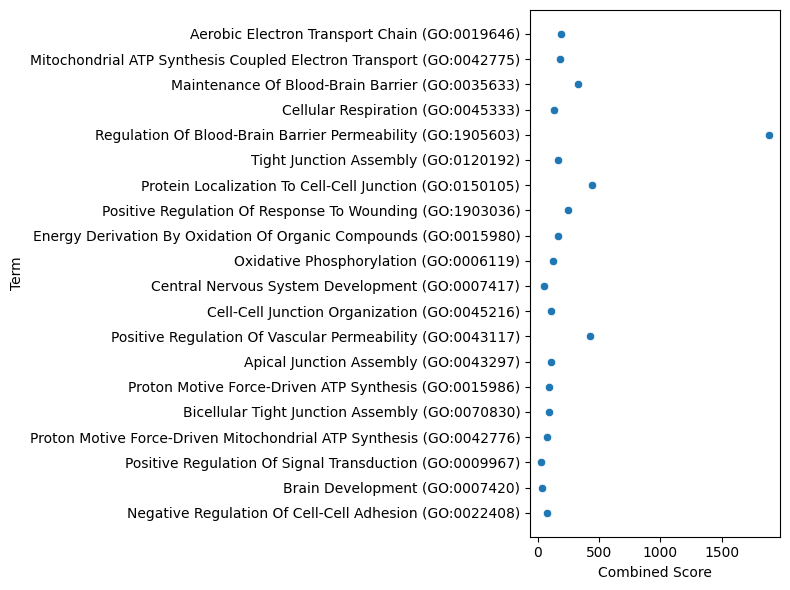

In [39]:

top = enr_coding.results.head(20)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=top,
    x="Combined Score",
    y="Term"
)

plt.tight_layout()
plt.show()


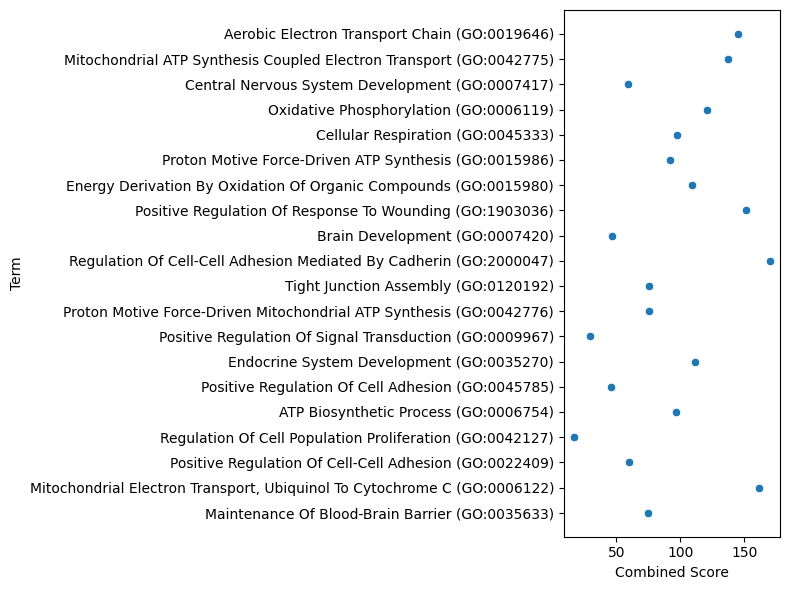

In [40]:
top = enr_ncrna.results.head(20)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=top,
    x="Combined Score",
    y="Term"
)

plt.tight_layout()
plt.show()



# Ensayo 3. Actividad de vías mediante PROGENy

## Objetivo

Inferir actividad funcional de rutas de señalización.


In [41]:

progeny = dc.op.progeny(
    organism="human",
    top=500
)

progeny.head()


,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40


In [42]:
adata_tmp_coding = adata_coding_common.copy()
adata_tmp_ncrna = adata_ncrna_common.copy()

In [43]:
progeny_genes = progeny["target"].unique()
common_genes_coding = adata_tmp_coding.var_names.intersection(progeny_genes)

print("Genes PROGENy encontrados en adata_tmp_coding:", len(common_genes_coding))

adata_coding_progeny = adata_tmp_coding[:, common_genes_coding].copy()

print(adata_coding_progeny)

Genes PROGENy encontrados en adata_tmp_coding: 5049
AnnData object with n_obs × n_vars = 39823 × 5049
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcount

In [44]:
progeny_genes = progeny["target"].unique()
common_genes_ncrna = adata_tmp_ncrna.var_names.intersection(progeny_genes)

print("Genes PROGENy encontrados en adata_tmp_ncrna:", len(common_genes_ncrna))

adata_ncrna_progeny = adata_tmp_ncrna[:, common_genes_ncrna].copy()

print(adata_ncrna_progeny)

Genes PROGENy encontrados en adata_tmp_ncrna: 5042
AnnData object with n_obs × n_vars = 39823 × 5042
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'Condition', 'DoubletClass', 'DoubletScore', 'Outlier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'S_score', 'G2M_score', 'phase', 'preannotation', 'preannotation_score', 'leiden_combat_0_5', 'leiden_final', 'annotation', 'annotation_score'
    var: 'n_cells', 'highly_variable'
    uns: 'Condition_colors', 'Sample_colors', 'annotation_colors', 'leiden_combat_0_5', 'leiden_final_colors', 'log1p', 'neighbors', 'pca', 'preannotation_colors', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_pca_combat', 'X_umap'
    varm: 'PCs'
    layers: 'combat', 'counts', 'logcounts

In [45]:

res_coding = dc.mt.mlm(
    data=adata_coding_progeny,
    net=progeny,
    verbose=True
)

2026-06-18 18:52:48 | [INFO] mlm - Running mlm
2026-06-18 18:52:48 | [INFO] Extracted omics mat with 39823 rows (observations) and 5049 columns (features)
2026-06-18 18:52:48 | [INFO] Network adjacency matrix has 5049 unique features and 14 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-06-18 18:52:50 | [INFO] mlm - fitting 14 multivariate models of 5049 observations with 5034 degrees of freedom
2026-06-18 18:53:00 | [INFO] mlm - done


In [46]:
res_ncrna = dc.mt.mlm(
    data=adata_ncrna_progeny,
    net=progeny,
    verbose=True
)

2026-06-18 18:53:00 | [INFO] mlm - Running mlm
2026-06-18 18:53:00 | [INFO] Extracted omics mat with 39823 rows (observations) and 5042 columns (features)
2026-06-18 18:53:00 | [INFO] Network adjacency matrix has 5042 unique features and 14 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-06-18 18:53:01 | [INFO] mlm - fitting 14 multivariate models of 5042 observations with 5027 degrees of freedom
2026-06-18 18:53:11 | [INFO] mlm - done


In [47]:
print(adata_coding_progeny.obsm.keys())

KeysView(AxisArrays with keys: X_pca, X_pca_combat, X_umap, score_mlm, padj_mlm)


In [48]:
print(adata_ncrna_progeny.obsm.keys())

KeysView(AxisArrays with keys: X_pca, X_pca_combat, X_umap, score_mlm, padj_mlm)


In [49]:


acts_coding = adata_coding_progeny.copy()

acts_coding.obsm["score_mlm"]

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
barcode,,,,,,,,,,,,,,
ATCGTAGGTAGTGTGG-GSM5514787_control,0.222178,2.890492,-0.712624,0.323298,2.663087,-2.241295,-3.922711,1.010037,-2.443568,2.934585,-0.936293,-0.895667,0.320448,-7.153328
CCCTCTCAGCCTATTG-GSM5514787_control,1.349997,-1.258882,-1.523058,1.948762,2.143279,-1.936956,0.336029,0.004909,-1.653234,0.339660,-1.535148,0.571054,-0.685757,-5.966498
GCAACCGGTGCACATT-GSM5514787_control,-0.598134,-1.950402,-2.391307,0.615133,-1.066425,-4.330338,-1.705646,-1.023978,-2.307665,-0.197916,-4.460503,-1.381975,-1.972691,-6.966290
ATCGTGAGTGGAAATT-GSM5514787_control,-0.019679,0.992187,-1.163669,-0.023675,3.791354,1.059416,-1.688563,1.827294,-2.946776,1.976714,-1.119957,0.664302,-0.099658,-8.574778
ATGAGGGAGGATTCCT-GSM5514787_control,0.012132,2.173104,-1.267029,1.115449,2.123670,-0.710058,0.231079,1.714825,-2.604062,1.377777,-1.372688,0.093669,-0.159038,-9.576758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGGGTGTGTGTACAGG-GSM5514794_tumor,-0.443918,-0.153885,0.565013,6.006804,-0.333717,-0.434742,-0.697338,-1.686647,-1.158379,3.866191,-0.214570,-0.576904,-0.263730,-0.772897
ATGAGTCCAGATACTC-GSM5514794_tumor,-0.593442,3.224762,-1.126269,5.567993,-0.450003,-4.210026,-0.440821,-2.616782,-0.710730,0.576418,0.573363,-0.488358,-0.819475,0.762624
TTGCATTCATACCATG-GSM5514794_tumor,-0.942996,1.893345,-1.557701,4.559469,0.603568,-2.445507,-2.776583,-1.533087,-0.904305,2.933299,0.623239,-0.476604,-1.011836,-9.162120


In [50]:
acts_ncrna = adata_ncrna_progeny.copy()

acts_ncrna.obsm["score_mlm"]

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
barcode,,,,,,,,,,,,,,
ATCGTAGGTAGTGTGG-GSM5514787_control,0.374561,2.648733,-0.773496,0.348669,2.311452,-1.681686,-3.862424,1.077763,-2.469148,3.176781,-0.668136,-0.788379,0.342110,-7.026588
CCCTCTCAGCCTATTG-GSM5514787_control,1.383278,-1.239923,-1.605230,2.073115,2.013418,-1.662598,0.653638,0.085496,-1.540695,0.254276,-1.550443,0.942474,-0.695772,-5.873926
GCAACCGGTGCACATT-GSM5514787_control,-0.544026,-1.898832,-2.133467,0.331559,-1.265715,-3.941944,-1.555044,-1.246247,-2.250963,-0.177423,-4.711249,-0.896967,-1.800346,-6.723110
ATCGTGAGTGGAAATT-GSM5514787_control,-0.194041,0.780963,-1.188309,-0.273961,3.680166,1.514589,-1.567085,1.736215,-2.910257,2.091684,-1.052720,0.906674,0.121592,-8.751402
ATGAGGGAGGATTCCT-GSM5514787_control,0.104689,1.959020,-1.141488,0.963691,1.934265,-0.065803,0.443161,1.239038,-2.647262,1.429973,-1.334585,0.336419,-0.210209,-9.691653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGGGTGTGTGTACAGG-GSM5514794_tumor,-0.440334,-0.298252,0.560771,5.848205,-1.015790,-0.174170,-0.498088,-1.327384,-0.897798,3.802882,-0.445406,-1.668214,-0.257805,-0.386983
ATGAGTCCAGATACTC-GSM5514794_tumor,0.862385,3.015275,-1.555712,5.078022,-0.373467,-3.566719,-0.656418,-1.710826,-0.797618,0.698113,0.532195,-0.507491,-1.305571,0.752383
TTGCATTCATACCATG-GSM5514794_tumor,-0.518277,1.559894,-1.348508,4.529012,0.467478,-1.831705,-2.404561,-1.228733,-0.661285,2.600799,0.819430,-0.496210,-1.553548,-8.944321


In [51]:
scores_mlm_coding = adata_coding_progeny.obsm["score_mlm"].copy()

scores_mlm_coding["Condition"] = adata_coding_progeny.obs["Condition"].values

scores_mlm_coding.head()

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53,Condition
barcode,,,,,,,,,,,,,,,
ATCGTAGGTAGTGTGG-GSM5514787_control,0.222178,2.890492,-0.712624,0.323298,2.663087,-2.241295,-3.922711,1.010037,-2.443568,2.934585,-0.936293,-0.895667,0.320448,-7.153328,control
CCCTCTCAGCCTATTG-GSM5514787_control,1.349997,-1.258882,-1.523058,1.948762,2.143279,-1.936956,0.336029,0.004909,-1.653234,0.339660,-1.535148,0.571054,-0.685757,-5.966498,control
GCAACCGGTGCACATT-GSM5514787_control,-0.598134,-1.950402,-2.391307,0.615133,-1.066425,-4.330338,-1.705646,-1.023978,-2.307665,-0.197916,-4.460503,-1.381975,-1.972691,-6.966290,control
ATCGTGAGTGGAAATT-GSM5514787_control,-0.019679,0.992187,-1.163669,-0.023675,3.791354,1.059416,-1.688563,1.827294,-2.946776,1.976714,-1.119957,0.664302,-0.099658,-8.574778,control
ATGAGGGAGGATTCCT-GSM5514787_control,0.012132,2.173104,-1.267029,1.115449,2.123670,-0.710058,0.231079,1.714825,-2.604062,1.377777,-1.372688,0.093669,-0.159038,-9.576758,control


In [52]:
scores_mlm_ncrna = adata_ncrna_progeny.obsm["score_mlm"].copy()

scores_mlm_ncrna["Condition"] = adata_ncrna_progeny.obs["Condition"].values

scores_mlm_ncrna.head()

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53,Condition
barcode,,,,,,,,,,,,,,,
ATCGTAGGTAGTGTGG-GSM5514787_control,0.374561,2.648733,-0.773496,0.348669,2.311452,-1.681686,-3.862424,1.077763,-2.469148,3.176781,-0.668136,-0.788379,0.342110,-7.026588,control
CCCTCTCAGCCTATTG-GSM5514787_control,1.383278,-1.239923,-1.605230,2.073115,2.013418,-1.662598,0.653638,0.085496,-1.540695,0.254276,-1.550443,0.942474,-0.695772,-5.873926,control
GCAACCGGTGCACATT-GSM5514787_control,-0.544026,-1.898832,-2.133467,0.331559,-1.265715,-3.941944,-1.555044,-1.246247,-2.250963,-0.177423,-4.711249,-0.896967,-1.800346,-6.723110,control
ATCGTGAGTGGAAATT-GSM5514787_control,-0.194041,0.780963,-1.188309,-0.273961,3.680166,1.514589,-1.567085,1.736215,-2.910257,2.091684,-1.052720,0.906674,0.121592,-8.751402,control
ATGAGGGAGGATTCCT-GSM5514787_control,0.104689,1.959020,-1.141488,0.963691,1.934265,-0.065803,0.443161,1.239038,-2.647262,1.429973,-1.334585,0.336419,-0.210209,-9.691653,control


In [53]:

mean_scores_by_condition_coding = scores_mlm_coding.groupby("Condition").mean()

mean_scores_by_condition_coding

/tmp/ipykernel_2707/3088482306.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scores_by_condition_coding = scores_mlm_coding.groupby("Condition").mean()


,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Condition,,,,,,,,,,,,,,
control,0.355015,-0.049475,-0.966066,1.205240,1.950843,-1.850742,-0.274002,-0.528193,-1.271330,0.816706,-0.507574,0.123726,-0.169873,-5.143544
omt,0.478172,-0.836513,-0.805915,1.738926,1.336201,-0.805820,0.906132,0.636924,-0.355113,-0.220436,-1.404723,0.426053,-0.717674,-6.577056
tumor,0.103436,-1.403990,-1.062105,1.856268,2.079856,-1.434354,-1.636429,1.097812,-1.095410,0.871386,-2.841621,-0.143908,-1.394302,-7.614178


In [54]:
mean_scores_by_condition_ncrna = scores_mlm_ncrna.groupby("Condition").mean()

mean_scores_by_condition_ncrna

/tmp/ipykernel_2707/2925531589.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scores_by_condition_ncrna = scores_mlm_ncrna.groupby("Condition").mean()


,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Condition,,,,,,,,,,,,,,
control,0.390070,-0.155603,-0.966157,1.225487,1.906753,-1.525727,-0.141271,-0.528263,-1.234019,0.842084,-0.515397,0.266361,-0.180275,-5.055080
omt,0.556031,-0.843281,-0.861532,1.781386,1.358788,-0.578255,1.009453,0.637447,-0.308142,-0.178028,-1.432536,0.510880,-0.755064,-6.496088
tumor,0.190050,-1.405432,-1.040919,1.679664,2.058413,-1.149650,-1.566261,1.074473,-1.036078,0.904488,-2.894003,-0.032074,-1.468386,-7.484408


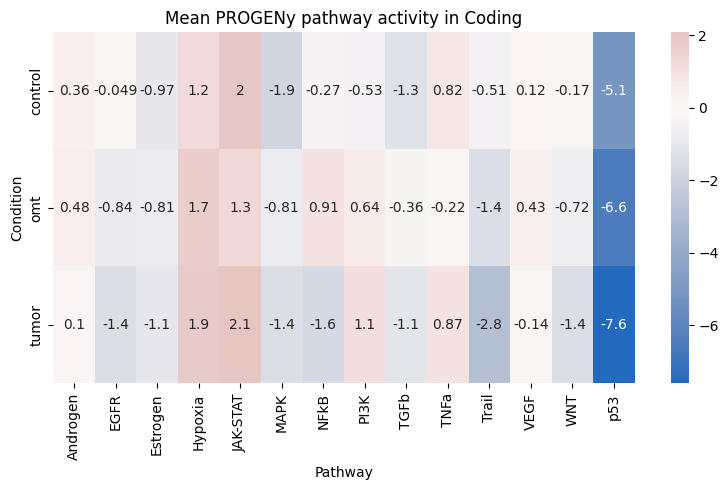

In [55]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    mean_scores_by_condition_coding,
    cmap="vlag",
    center=0,
    annot=True
)

plt.title("Mean PROGENy pathway activity in Coding")
plt.xlabel("Pathway")
plt.ylabel("Condition")
plt.tight_layout()
plt.show()

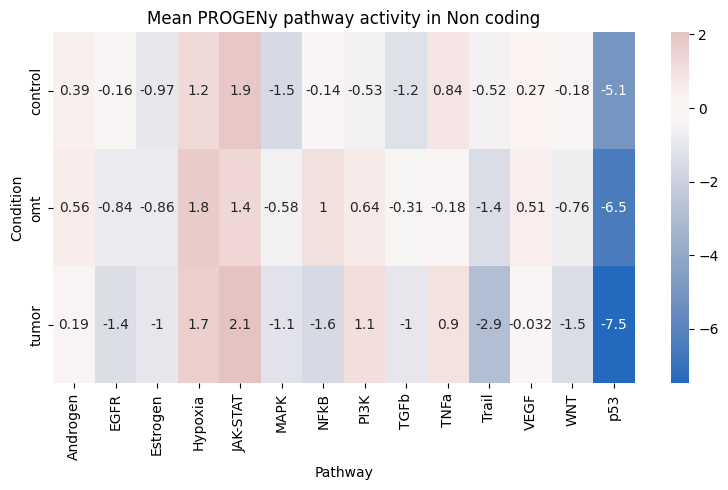

In [56]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    mean_scores_by_condition_ncrna,
    cmap="vlag",
    center=0,
    annot=True
)

plt.title("Mean PROGENy pathway activity in Non coding")
plt.xlabel("Pathway")
plt.ylabel("Condition")
plt.tight_layout()
plt.show()


# Ensayo 4. ncRNAs

## Objetivo

Identificar genes no codificantes potencialmente implicados en cáncer de ovario.


In [57]:

var = adata_ncrna.var.copy()

var.head()


,n_cells,highly_variable
5S-rRNA-ENSG00000277411.1,92,False
5S-rRNA-ENSG00000285626.1,83,False
A1BG,55,False
A1BG-AS1,2705,False
A1CF,115,False



## Filtrado de ncRNAs

Adaptar según la anotación disponible.


In [58]:

ncrna_genes = adata_ncrna.var_names[
    adata_ncrna.var_names.str.contains(
        "MIR|Mir|LINC|lnc",
        regex=True
    )
]

len(ncrna_genes)


2012

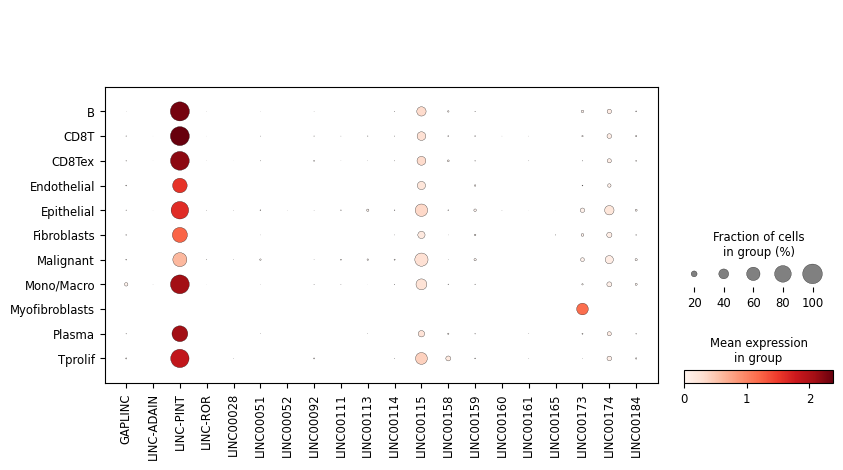

In [59]:

sc.pl.dotplot(
    adata_ncrna,
    var_names=ncrna_genes[:20],
    groupby="annotation"
)


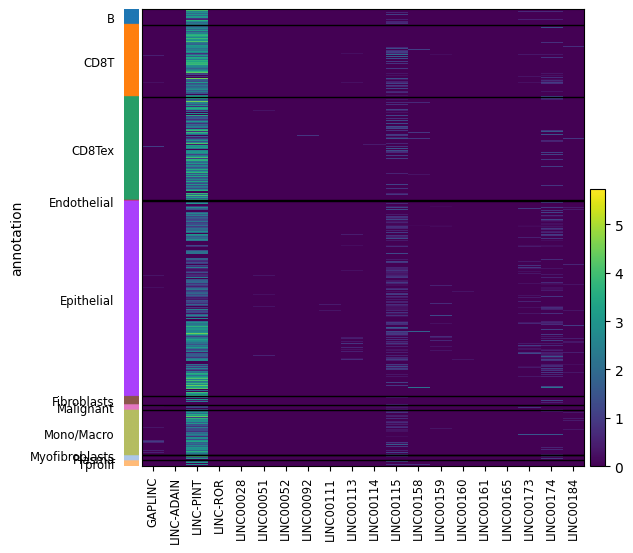

In [60]:

sc.pl.heatmap(
    adata_ncrna,
    var_names=ncrna_genes[:20],
    groupby="annotation"
)



# Resumen final

El estudiante deberá resumir:

1. Qué genes cambian.
2. Qué procesos biológicos cambian.
3. Qué vías están activadas.
4. Qué ncRNAs aportan información adicional.

Comparar siempre los resultados obtenidos en:

- Coding-only.
- Coding + ncRNA.
